In [1]:

#load the dataset
import pandas as pd
df=pd.read_csv("data.csv")


#check the structure of the dataset
print("\nFIRST 5 ROWS:")
print(df.head())

print("DATASET SHAPE:",df.shape)

print("columns in the dataset:")
print(df.columns)

#check for data types
print("data types of each column:")
print(df.dtypes)#


#check for missing values
missing_total = int(df.isna().sum().sum())
print(missing_total)

#check for duplicates
duplicates=df.duplicated().sum()
print("number of duplicate rows:")
print(duplicates) 

#statistical summary of numerical features
print("statistical summary of numerical features:")
print(df.describe())        





FIRST 5 ROWS:
   MATS3v  nHBint10  MATS3s  MATS3p  nHBDon_Lipinski  minHBint8  MATS3e  \
0  0.0908         0  0.0075  0.0173                0        0.0 -0.0436   
1  0.0213         0  0.1144 -0.0410                0        0.0  0.1231   
2  0.0018         0 -0.0156 -0.0765                2        0.0 -0.1138   
3 -0.0251         0 -0.0064 -0.0894                3        0.0 -0.0747   
4  0.0135         0  0.0424 -0.0353                0        0.0 -0.0638   

   MATS3c  minHBint2  MATS3m  ...   WTPT-4   WTPT-5  ETA_EtaP_L  ETA_EtaP_F  \
0  0.0409        0.0  0.1368  ...   0.0000   0.0000      0.1780      1.5488   
1 -0.0316        0.0  0.1318  ...   8.8660  19.3525      0.1739      1.3718   
2 -0.1791        0.0  0.0615  ...   5.2267  27.8796      0.1688      1.4395   
3 -0.1151        0.0  0.0361  ...   7.7896  24.7336      0.1702      1.4654   
4  0.0307        0.0  0.0306  ...  12.3240  19.7486      0.1789      1.4495   

   ETA_EtaP_B  nT5Ring  SHdNH  ETA_dEpsilon_C  MDEO-22     

target variable distribution:
Class
NonToxic    115
Toxic        56
Name: count, dtype: int64


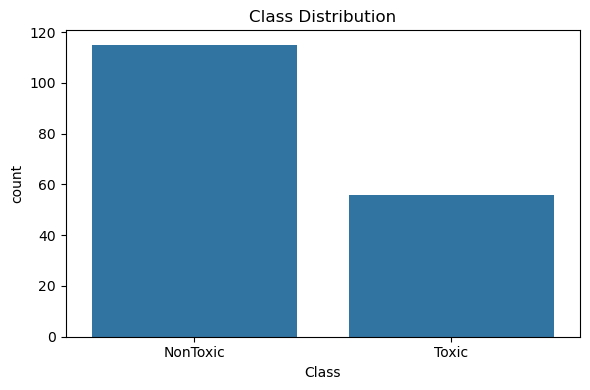

In [2]:
#Target variable Class distribution analysis
import matplotlib.pyplot as plt
import seaborn as sns

print("target variable distribution:")

print(df['Class'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title('Class Distribution')
plt.tight_layout()
plt.show()



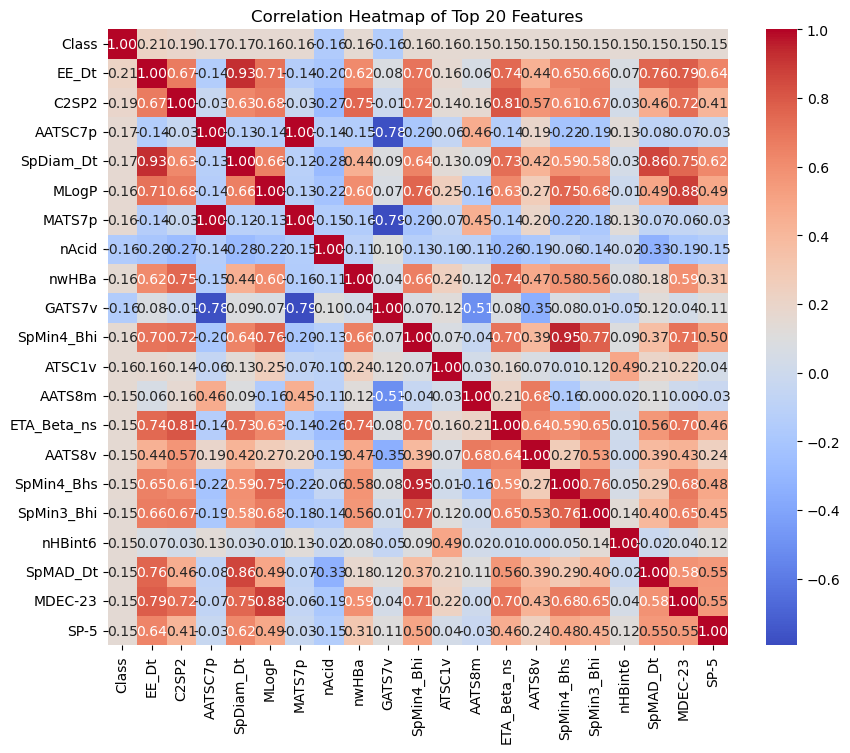

In [5]:
from sklearn.preprocessing import LabelEncoder

#correlation analysis for top 20 features
# Compute correlation matrix

correlation_matrix = df.corr(numeric_only=True)
# Get the top 20 features most correlated with the target variable 'Class'
# Encode the target variable 'Class' to numeric for correlation calculation
encoder = LabelEncoder()
df_encoded = df.copy()
df_encoded['Class'] = encoder.fit_transform(df_encoded['Class'])

# Compute correlation matrix including the encoded 'Class'
correlation_matrix = df_encoded.corr(numeric_only=True)

# Get the top 20 features most correlated with the target variable 'Class'
top_features = correlation_matrix['Class'].abs().sort_values(ascending=False).head(21).index
# Plot the correlation heatmap for the top features         
plt.figure(figsize=(10,8))
sns.heatmap(df_encoded[top_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Top 20 Features')
plt.show()
    



Number of features after removing highly correlated: 477
Dropped features: ['SpMax8_Bhm', 'SpMax8_Bhe', 'SpMax8_Bhp', 'SpMax8_Bhv', 'ATS7v', 'ATS7i', 'ATS7m', 'ATS7e', 'SpMax_DzZ', 'StN'] ...


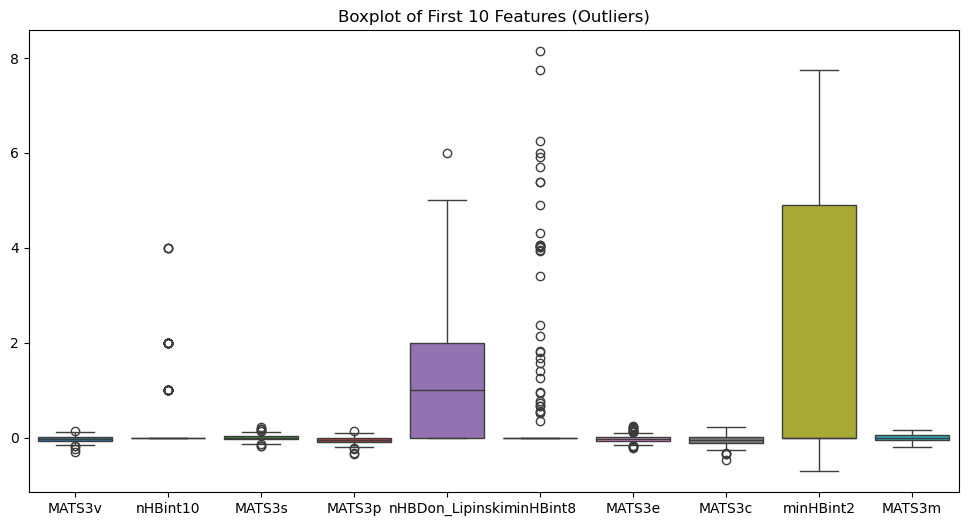

In [6]:
# Remove highly correlated features
import numpy as np

def remove_highly_correlated(df, threshold=0.9):
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    return df.drop(columns=to_drop), to_drop

# Exclude target variable
features_reduced, dropped_features = remove_highly_correlated(df.drop(columns=['Class']))

print("\nNumber of features after removing highly correlated:", features_reduced.shape[1])  
print("Dropped features:", dropped_features[:10], "...")  # show first 10

# Outlier Analysis (first 10 features or fewer)
plt.figure(figsize=(12,6))
sns.boxplot(data=features_reduced.iloc[:, :min(10, features_reduced.shape[1])])
plt.title("Boxplot of First 10 Features (Outliers)")
plt.show()

Series([], dtype: int64)
0
1203
                  mean           std       min           max
VR1_D    696551.476871  2.511270e+06  140.6167  1.900019e+07
VR1_Dzi  544934.130822  2.356811e+06    0.0000  1.700019e+07
VR1_Dzv  445222.881129  1.988423e+06    0.0000  1.700019e+07
VR1_Dzp  445291.041080  1.988410e+06    0.0000  1.700020e+07
VR1_Dze  445566.167629  1.988349e+06    0.0000  1.700018e+07
VR1_Dzm  445582.987618  1.988346e+06    0.0000  1.700018e+07
VR1_DzZ  445587.698859  1.988345e+06    0.0000  1.700018e+07
VR1_Dt   503786.155221  1.825734e+06  100.6868  1.900021e+07
VR1_Dzs  135661.122937  1.336949e+06    0.0000  1.700016e+07
VR2_D     17250.403500  6.099545e+04    7.8120  4.418650e+05
VR2_Dzi   13738.147894  5.903000e+04    0.0000  4.359022e+05
VR2_Dzv   11182.386067  4.930410e+04    0.0000  4.359023e+05


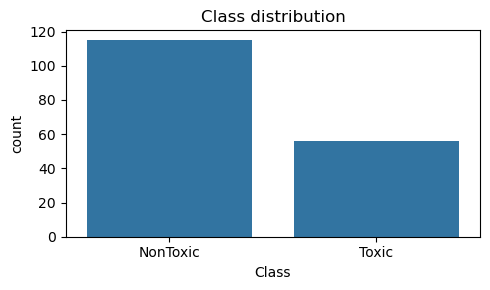

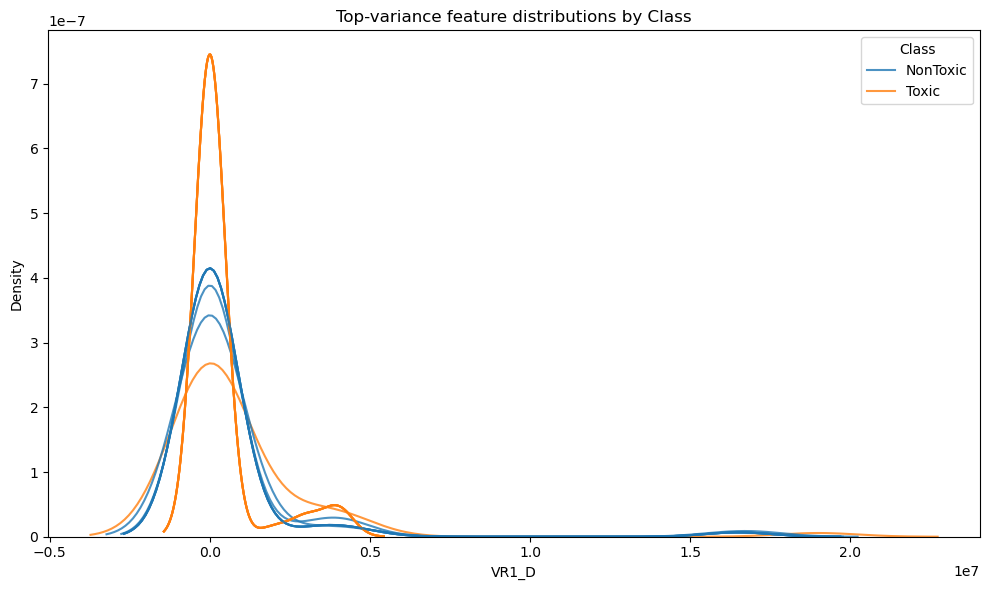

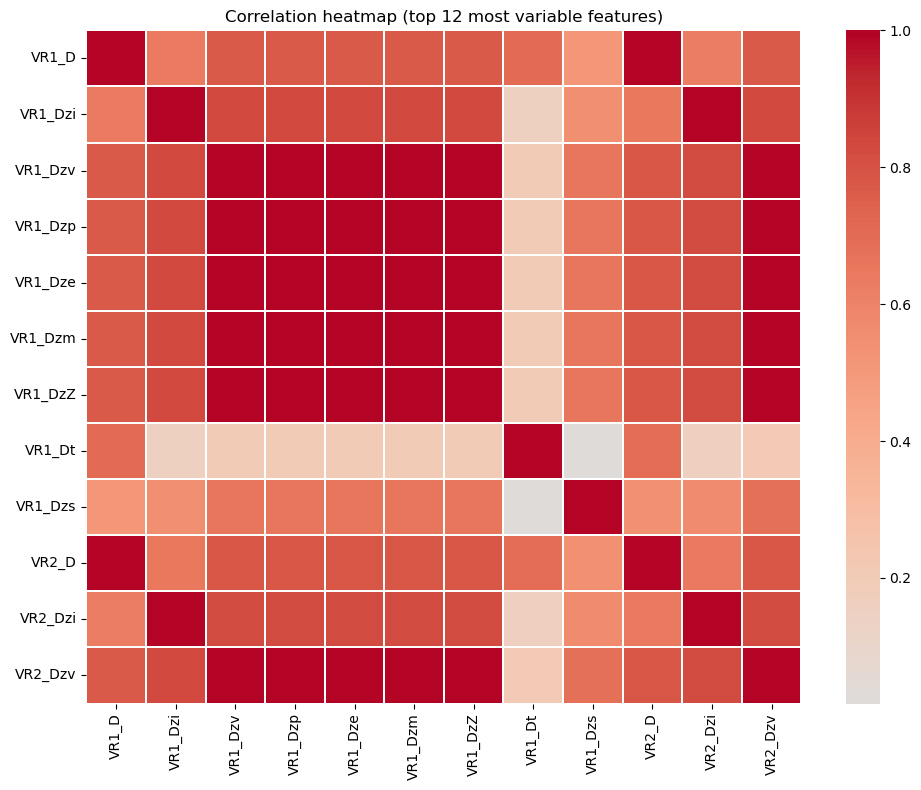

In [7]:
# Continuation of  EDA: 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

missing_counts = df.isna().sum().sort_values(ascending=False)
missing_nonzero = missing_counts[missing_counts > 0]
print(missing_nonzero.head(10))
print(int(df.isna().sum().sum()))

num_cols = df.drop(columns=["Class"]).select_dtypes(include=[np.number]).columns
print(len(num_cols))

# Summary for a small subset of features (top variance)
feat_vars = df[num_cols].var().sort_values(ascending=False)
top_feats = list(feat_vars.head(12).index)
print(df[top_feats].describe().T[["mean","std","min","max"]].head(12))

# Plots
plt.figure(figsize=(5,3))
sns.countplot(data=df, x="Class", order=df["Class"].value_counts().index)
plt.title("Class distribution")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
for feat_name in top_feats[:6]:
    sns.kdeplot(data=df, x=feat_name, hue="Class", common_norm=False, fill=False, alpha=0.8)
plt.title("Top-variance feature distributions by Class")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df[top_feats].corr(), cmap="coolwarm", center=0, linewidths=0.2)
plt.title("Correlation heatmap (top 12 most variable features)")
plt.tight_layout()
plt.show()

In [8]:
#processing and feature selection
#import libraries
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

#separate features and target variable(# NonToxic = 0 # Toxic = 1)
df = pd.read_csv("data.csv")
X = df.drop(columns=['Class'])
y = df['Class']

#encode target variable if it's categorical
if y.dtype == 'object':
    encoder = LabelEncoder()
y = encoder.fit_transform(y)

print(np.unique(y))

#remove low variance features
selector = VarianceThreshold(threshold=0.01)

X_var = selector.fit_transform(X)

print("Original features:", X.shape[1])
print("Features after variance threshold:", X_var.shape[1])

#scale features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

#feature selection using SelectKBest
selector = SelectKBest(score_func=f_classif, k=50)

X_selected = selector.fit_transform(X_scaled, y)

print("Final selected features:", X_selected.shape[1])

[0 1]
Original features: 1203
Features after variance threshold: 994
Final selected features: 50


In [9]:
#cross-validation and model training
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model = RandomForestClassifier(n_estimators=200, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
#cross validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
scores = cross_val_score(model, X_selected, y, cv=cv, scoring='accuracy')
print("Cross-validation accuracy scores:", scores)      
print("Mean cross-validation accuracy:", scores.mean())
print("Standard Deviation:", scores.std())

    # Train Model
model.fit(X_train, y_train)

    # Predictions
y_pred = model.predict(X_test)

    # Evaluation

accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []
accuracy_scores.append(accuracy_score(y_test, y_pred))
precision_scores.append(precision_score(y_test, y_pred))
recall_scores.append(recall_score(y_test, y_pred))
f1_scores.append(f1_score(y_test, y_pred))

print("Accuracy scores:", accuracy_scores)
print("Precision scores:", precision_scores)
print("Recall scores:", recall_scores)
print("F1 scores:", f1_scores)


















Cross-validation accuracy scores: [0.65714286 0.64705882 0.67647059 0.52941176 0.55882353]
Mean cross-validation accuracy: 0.613781512605042
Standard Deviation: 0.058405719074590745
Accuracy scores: [0.6285714285714286]
Precision scores: [0.25]
Recall scores: [0.09090909090909091]
F1 scores: [0.13333333333333333]
